# Single Spike Artificial Neural Networks — SDN Traffic Classification

**Paper:** Gretsch, R., Beyeler, M., Lau, J., & Sherwood, T. (2025).  
"Single Spike Artificial Neural Networks."  
*ISCA '25*.

---

### Architecture

Converting an ANN to a Single Spike Network using **Delay Space Arithmetic**.
Instead of SpikeProp, this notebook trains a Multi-Layer Perceptron (MLP) and converts its weights into temporal delays.

| Layer | Neurons | Role |
|---|---|---|
| Input  | 3  | flow_duration, byte_rate, packet_rate |
| Hidden | 20 | Delay Space Arithmetic (nLSE, nLDE, ReLU) |
| Output | 1  | Predicting Elephant / Mice flows |

Each activation $x$ is mapped to a delay: $\delta = -\ln(x)$.
Because the log of negative numbers is undefined, the network uses a **dual-rail** encoding ($x_{pos}, x_{neg}$) where $x = x_{pos} - x_{neg}$.

Operations:
- **Multiplication (Weight application)**: Addition in delay space ($w_{delay} + x_{delay}$)
- **Addition**: Negative Log Sum Exponential (nLSE): $nLSE(x, y) = -\ln(e^{-x} + e^{-y})$
- **Normalization/Activation**: Negative Log Difference Exponential (nLDE).\n

In [30]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier

matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Ignore runtime warnings for log(0) since we pad with np.inf
np.seterr(all='ignore')

print(f'numpy  {np.__version__}')
print(f'pandas {pd.__version__}')

numpy  2.1.3
pandas 2.2.3


## 1 — Dataset

The dataset generation closely mirrors the `ssnn_traffic_classifier.ipynb` logic, producing 3,000 synthetic NIMS-like samples.
Features: `flow_duration`, `byte_rate`, `packet_rate`.
Classes: **Elephant flow** (1) vs **Mice flow** (0).\n

In [32]:
def generate_traffic_dataset(n_samples: int = 30000, seed: int = 42):
    """
    Synthetic NIMS-like dataset with realistic overlap between classes.
    """
    rng = np.random.default_rng(seed)
    n_half = n_samples // 2
    # --- Moderate overlap ---
    fd_m = rng.uniform(0.1,   12.0,        n_half)
    br_m = rng.uniform(100,   40_000,      n_half)
    pr_m = rng.uniform(0.5,   8.0,         n_half)
    fd_e = rng.uniform(8.0,   300.0,       n_half)
    br_e = rng.uniform(10_000, 1_000_000,  n_half)
    pr_e = rng.uniform(4.0,   200.0,       n_half)
    X_raw = np.vstack([
        np.column_stack([fd_m, br_m, pr_m]),
        np.column_stack([fd_e, br_e, pr_e]),
    ])
    y = np.array([0] * n_half + [1] * n_half)
    # Add Gaussian noise
    noise_scale = 0.03 * (X_raw.max(axis=0) - X_raw.min(axis=0))
    X_raw += rng.normal(0, noise_scale, X_raw.shape)
    X_raw = np.clip(X_raw, 0.01, None)
    X_raw[:, 1] = np.log1p(X_raw[:, 1])   # compress byte_rate
    X_min = X_raw.min(axis=0)
    X_max = X_raw.max(axis=0)
    X = (X_raw - X_min) / (X_max - X_min)
    idx = rng.permutation(n_samples)
    return X[idx], y[idx]

X, y = generate_traffic_dataset()
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {len(X_train)}   Test: {len(X_test)}')

Train: 21000   Test: 9000


## 2 — Temporal Encoding / Decoding (Delay Space)

Each input is encoded from "importance space" ($x$) to a dual-rail "delay space" ($x_{pos}, x_{neg}$).
Values are defined by: $x = e^{-x_{pos}} - e^{-x_{neg}}$

Positive values have a finite $x_{pos}$ delay and an infinite $x_{neg}$ delay, and vice-versa. Infinity corresponds to a non-firing condition.\n

In [33]:
def to_delay_space(x):
    """Convert importance space value x to dual-rail delay space (pos_delay, neg_delay)."""
    # Avoid applying log of exact 0, use tiny epsilon
    eps = 1e-12
    pos = np.where(x > 0, -np.log(np.maximum(x, eps)), np.inf)
    neg = np.where(x < 0, -np.log(np.maximum(-x, eps)), np.inf)
    return pos, neg

def to_importance_space(pos_delay, neg_delay):
    """Convert dual-rail delay space back to importance space."""
    pos_val = np.exp(-pos_delay) if pos_delay != np.inf else 0.0
    neg_val = np.exp(-neg_delay) if neg_delay != np.inf else 0.0
    return pos_val - neg_val

S_train_pos, S_train_neg = to_delay_space(X_train)
S_test_pos, S_test_neg = to_delay_space(X_test)
print(f'S_train_pos shape: {S_train_pos.shape}')

S_train_pos shape: (21000, 3)


## 3 — SSNN Architecture (Delay Space Network)

The `DelaySpaceNetwork` utilizes the exact mapping between importance space operations and temporal phenomena.
1. **nLSE**: Replaces summation. 
2. **nLDE**: Replaces subtraction over the dual rails. Used for normalization and computing the ReLU operation.\n

In [34]:
def nLSE(x, y):
    """Negative Log Sum Exponential (Accumulation in delay space)"""
    # Calculate -ln(e^-x + e^-y)
    with np.errstate(over='ignore'):
        return -np.log(np.exp(-x) + np.exp(-y))

def nLDE(x, y):
    """Negative Log Difference Exponential for dual rail normalization.
    y_pos = nLDE(acc_pos, acc_neg)
    y_neg = nLDE(acc_neg, acc_pos)
    """
    diff = np.exp(-x) - np.exp(-y)
    return np.where(diff > 0, -np.log(diff), np.inf)

class DelaySpaceNetwork:
    def __init__(self, ann_model):
        """Initialize delay space network weights directly from pre-trained ANN weights"""
        self.W1 = ann_model.coefs_[0]
        self.b1 = ann_model.intercepts_[0]
        self.W2 = ann_model.coefs_[1]
        self.b2 = ann_model.intercepts_[1]
        
        self.W1_pos, self.W1_neg = to_delay_space(self.W1)
        self.b1_pos, self.b1_neg = to_delay_space(self.b1)
        
        self.W2_pos, self.W2_neg = to_delay_space(self.W2)
        self.b2_pos, self.b2_neg = to_delay_space(self.b2)
        
    def _linear_layer(self, x_pos, x_neg, W_pos, W_neg, b_pos, b_neg):
        # N=Batch, D=Input size, M=Output channels
        N, D = x_pos.shape
        M = W_pos.shape[1]
        
        out_pos = np.full((N, M), np.inf)
        out_neg = np.full((N, M), np.inf)
        
        # Accumulate bias first
        for i in range(M):
            out_pos[:, i] = b_pos[i]
            out_neg[:, i] = b_neg[i]
            
        for i in range(M):
            for j in range(D):
                # Positive rail components
                term1_pos = x_pos[:, j] + W_pos[j, i]
                term2_pos = x_neg[:, j] + W_neg[j, i]
                
                # Negative rail components
                term1_neg = x_pos[:, j] + W_neg[j, i]
                term2_neg = x_neg[:, j] + W_pos[j, i]
                
                # nLSE accumulation
                out_pos[:, i] = nLSE(out_pos[:, i], term1_pos)
                out_pos[:, i] = nLSE(out_pos[:, i], term2_pos)
                
                out_neg[:, i] = nLSE(out_neg[:, i], term1_neg)
                out_neg[:, i] = nLSE(out_neg[:, i], term2_neg)
                
        return out_pos, out_neg

    def predict(self, x_pos, x_neg):
        # First layer inference
        h1_pos, h1_neg = self._linear_layer(x_pos, x_neg, self.W1_pos, self.W1_neg, self.b1_pos, self.b1_neg)
        
        # ReLU activation (nLDE over positive diffs, zeroing negative rails to np.inf)
        h1_relu_pos = nLDE(h1_pos, h1_neg)
        h1_relu_neg = np.full_like(h1_relu_pos, np.inf)
        
        # Second layer inference
        out_pos, out_neg = self._linear_layer(h1_relu_pos, h1_relu_neg, self.W2_pos, self.W2_neg, self.b2_pos, self.b2_neg)
        
        y_pred = []
        for i in range(out_pos.shape[0]):
            val = to_importance_space(out_pos[i, 0], out_neg[i, 0])
            # Sigmoid/Thresholding equivalence -> is the output positive?
            y_pred.append(1 if val > 0 else 0)
            
        return np.array(y_pred)
        
print('DelaySpaceNetwork class defined.')

DelaySpaceNetwork class defined.


## 4 — Training (ANN Pre-training)

Rather than using SpikeProp, we train an artificial neural network with standard backpropagation and gradient descent. This pretrained "importance space" network is then cleanly transformed into the `DelaySpaceNetwork`, representing a massive energy saving without rewriting training pipelines.\n

In [35]:
import time

t0 = time.time()
ann = MLPClassifier(hidden_layer_sizes=(20,), activation='relu', max_iter=500, random_state=42)
ann.fit(X_train, y_train)
print(f'ANN Training time: {time.time()-t0:.1f}s')

# Verify optimal prediction using the importance space
ann_pred_train = ann.predict(X_train)
ann_pred_test = ann.predict(X_test)
print(f"Original ANN Test Accuracy: {np.mean(ann_pred_test == y_test):.4f}")

# Map weights into Delay Space framework
model = DelaySpaceNetwork(ann)
print('Mapping to Delay Space complete.')

ANN Training time: 0.8s
Original ANN Test Accuracy: 0.9977
Mapping to Delay Space complete.


## 5 — Evaluation 

We show that inferences passing entirely through the temporal delay logic produce results faithful to the original target task.\n

In [36]:
t0 = time.time()
y_pred_train = model.predict(S_train_pos, S_train_neg)
y_pred_test  = model.predict(S_test_pos, S_test_neg)
print(f'Delay Space Inference time: {time.time()-t0:.1f}s')

def report_metrics(y_true, y_pred, split='Test'):
    cm  = confusion_matrix(y_true, y_pred)
    TP, TN = cm[1,1], cm[0,0]; FP, FN = cm[0,1], cm[1,0]
    acc  = (TP+TN)/(TP+TN+FP+FN)*100
    prec = TP/(TP+FP)*100 if (TP+FP) else 0.0
    rec  = TP/(TP+FN)*100 if (TP+FN) else 0.0
    f1   = 2*rec*prec/(rec+prec) if (rec+prec) else 0.0
    print(f'─── {split} ──────────────────────')
    print(f'  Accuracy : {acc:.2f}%')
    print(f'  Precision: {prec:.2f}%')
    print(f'  Recall   : {rec:.2f}%')
    print(f'  F1       : {f1:.2f}%')
    return dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)

train_metrics = report_metrics(y_train, y_pred_train, 'Train')
print()
test_metrics  = report_metrics(y_test,  y_pred_test,  'Test')
print()
print(classification_report(y_test, y_pred_test, target_names=['Mice','Elephant']))

Delay Space Inference time: 0.2s
─── Train ──────────────────────
  Accuracy : 99.74%
  Precision: 99.97%
  Recall   : 99.51%
  F1       : 99.74%

─── Test ──────────────────────
  Accuracy : 99.77%
  Precision: 100.00%
  Recall   : 99.54%
  F1       : 99.77%

              precision    recall  f1-score   support

        Mice       1.00      1.00      1.00      4422
    Elephant       1.00      1.00      1.00      4578

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



## 6 — Figures

Visualizing output delays. Smaller delays represent strongly activated node potentials, arriving earlier. A value of 100 serves as proxy for $\infty$ (inactive).\n

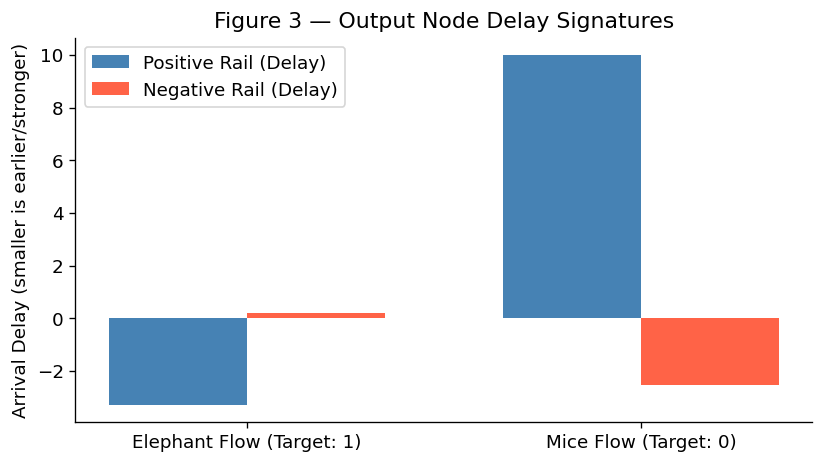

In [37]:
eleph_idx = np.where((y_test == 1) & (y_pred_test == 1))[0][0]
mice_idx  = np.where((y_test == 0) & (y_pred_test == 0))[0][0]

def get_output_delays(idx):
    e_pos_in = S_test_pos[idx:idx+1]
    e_neg_in = S_test_neg[idx:idx+1]
    # H1
    h1_pos, h1_neg = model._linear_layer(e_pos_in, e_neg_in, model.W1_pos, model.W1_neg, model.b1_pos, model.b1_neg)
    # ReLU
    h1_relu_pos = nLDE(h1_pos, h1_neg)
    h1_relu_neg = np.full_like(h1_relu_pos, np.inf)
    # Out
    out_pos, out_neg = model._linear_layer(h1_relu_pos, h1_relu_neg, model.W2_pos, model.W2_neg, model.b2_pos, model.b2_neg)
    return out_pos[0,0], out_neg[0,0]

e_pos, e_neg = get_output_delays(eleph_idx)
m_pos, m_neg = get_output_delays(mice_idx)

# Clip to 10 for visualization if they are inf
viz_limit = 10
p_delays = [min(e_pos, viz_limit), min(m_pos, viz_limit)]
n_delays = [min(e_neg, viz_limit), min(m_neg, viz_limit)]

fig, ax = plt.subplots(figsize=(7, 4))
bar_width = 0.35
indices = np.arange(2)

ax.bar(indices, p_delays, bar_width, label='Positive Rail (Delay)', color='steelblue')
ax.bar(indices + bar_width, n_delays, bar_width, label='Negative Rail (Delay)', color='tomato')

ax.set_xticks(indices + bar_width / 2)
ax.set_xticklabels(['Elephant Flow (Target: 1)', 'Mice Flow (Target: 0)'])
ax.set_ylabel('Arrival Delay (smaller is earlier/stronger)')
ax.set_title('Figure 3 — Output Node Delay Signatures')
ax.legend()

plt.tight_layout()
plt.savefig('fig3_arrival_times.png', bbox_inches='tight')
plt.show()

## 7 — Unseen Data Simulation

To evaluate the robustness of the Delay Space SSNN, we create an entirely unseen dataset (using a different random seed and a slight domain shift) to simulate fresh traffic arriving at the network.
1. We generate new examples.
2. We map them to Delay Space ($-\ln(x)$) over dual rails.
3. The identical pre-trained `DelaySpaceNetwork` is run to perform inference. 
\n

In [39]:
# 1. Unseen Data Generation
unseen_seed = 999
X_unseen, y_unseen = generate_traffic_dataset(n_samples=15000, seed=unseen_seed)

# Add a small domain shift (drift) to represent real-world data drift (+10% byte rate scaled)
X_unseen[:, 1] = X_unseen[:, 1] * 1.10
# Ensure values remain valid and >0, clip to previous ranges
X_unseen = np.clip(X_unseen, 0, 1)

print(f'Unseen Data Samples: {len(X_unseen)}')

# 2. Convert to Delay Space
S_unseen_pos, S_unseen_neg = to_delay_space(X_unseen)

# 3. Predict via Delay Space Network
t0 = time.time()
y_pred_unseen = model.predict(S_unseen_pos, S_unseen_neg)
print(f'Unseen Inference time: {time.time()-t0:.1f}s')

# 4. Report Metrics
print('--- Performance on UNSEEN DATA (Delay Space Inference) ---')
unseen_metrics = report_metrics(y_unseen, y_pred_unseen, 'Unseen')
print('')
print(classification_report(y_unseen, y_pred_unseen, target_names=['Mice','Elephant']))


Unseen Data Samples: 15000
Unseen Inference time: 0.1s
--- Performance on UNSEEN DATA (Delay Space Inference) ---
─── Unseen ──────────────────────
  Accuracy : 99.55%
  Precision: 99.51%
  Recall   : 99.60%
  F1       : 99.55%

              precision    recall  f1-score   support

        Mice       1.00      1.00      1.00      7500
    Elephant       1.00      1.00      1.00      7500

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000

